In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("Gender_Data.csv")
df2 = pd.read_csv("data.csv")
data = pd.concat([df1, df2], axis=0)

In [3]:
data.head()

,Name,Gender,Count,Probability
0,Aaban,0,NaN,NaN
1,Aabharan,0,NaN,NaN
2,Aabhas,0,NaN,NaN
3,Aabhat,0,NaN,NaN
4,Aabheer,0,NaN,NaN


In [4]:
data.drop(columns=['Count','Probability'], inplace=True)
data.sample(10)

,Name,Gender
64716,Daun,M
123789,Kezra,F
62230,Rixton,M
16677,PonniValavan,0
6478,Coltin,M
9832,Jeykanth,0
129986,Sermara,F
41260,Maronda,F
85740,Yashekia,F
20445,Shani,0


In [5]:
data['Gender'].value_counts()

,count
Gender,
F,89749
M,57520
0,29014
1,24968


In [6]:
data['Gender'] = data['Gender'].replace({0: 'M', 1: 'F'})
data.sample(10)

,Name,Gender
82073,Sarne,F
17237,Palanisamy,M
25667,Upjit,M
113390,Namarta,F
16083,Weylin,M
29025,Aabinsha,F
129290,Rukhsna,F
30848,Abirame,F
79770,Taneca,F
38090,Wake,M


In [7]:
data['Gender'].value_counts()

,count
Gender,
F,114717
M,86534


In [8]:
data.isnull().sum()

,0
Name,0
Gender,0


In [9]:
len(data['Name'].unique()) == len(data)

False

In [10]:
len(data) - len(data['Name'].unique())

21053

In [11]:
# Identify names with both 'M' and 'F' genders
ambiguous_names = data[data.duplicated('Name', keep=False)]

# Create a new column 'neutral' and set it to True for ambiguous names
data['Neutral'] = data['Name'].isin(ambiguous_names['Name'])

# Update gender to 'N' (neutral) for ambiguous names
data.loc[data['Neutral'], 'Gender'] = 'N'

# Drop duplicate rows to keep only one entry for each name
data = data.drop_duplicates(subset=['Name', 'Gender'])

In [12]:
data['Gender'].unique()

array(['N', 'M', 'F'], dtype=object)

In [13]:
data.head()

,Name,Gender,Neutral
0,Aaban,N,True
1,Aabharan,M,False
2,Aabhas,M,False
3,Aabhat,M,False
4,Aabheer,M,False


In [14]:
# Removing that temporary coloumn created.
data.drop(columns = ['Neutral'], inplace = True)

In [15]:
# Just making this easier to view sorting
data.sort_values(by = "Name", inplace = True)

In [16]:
data.head()

,Name,Gender
112246,A,N
115618,A'Aff,F
133954,A'Aron,M
115619,A'Dele,F
115620,A'Isha,F


In [17]:
data = data[data['Gender'] != 'N']
data.head()

,Name,Gender
115618,A'Aff,F
133954,A'Aron,M
115619,A'Dele,F
115620,A'Isha,F
115621,A'Ishah,F


In [18]:
# What unique characters in the names?
characters_unique = set()
cols = ['Name']
for col in cols:
    for value in data[col]:
        for letter in value:
            if letter not in string.ascii_lowercase and letter not in string.ascii_uppercase:
                characters_unique.add(letter)

characters_unique

{'"',
 '&',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 '/',
 '0',
 '1',
 '5',
 '7',
 '8',
 '9',
 ';',
 '?',
 '@',
 '[',
 '¡',
 'à',
 'ö',
 'œ',
 '…'}

In [19]:
import re
import unicodedata
def clean_name(name):
    # Convert to string
    name = str(name)

    # Normalize unicode (é → e, ö → o)
    name = unicodedata.normalize('NFKD', name)

    # Encode to ASCII (ignore non-ascii parts)
    name = name.encode('ascii', 'ignore').decode('utf-8')

    # Keep only alphabets
    name = re.sub(r'[^a-zA-Z]', '', name)

    return name.lower()

In [20]:
data['Name'] = data['Name'].apply(clean_name)
data.head()

,Name,Gender
115618,aaff,F
133954,aaron,M
115619,adele,F
115620,aisha,F
115621,aishah,F


In [21]:
data['Name'] = data['Name'].replace(r'^\s*$', np.nan, regex=True)

In [22]:
data.isnull().sum()

,0
Name,0
Gender,0


In [23]:
import string
# What unique characters in the names?
characters_unique = set()
cols = ['Name']
for col in cols:
    for value in data[col]:
        for letter in value:
            if letter not in string.ascii_lowercase and letter not in string.ascii_uppercase:
                characters_unique.add(letter)

characters_unique

set()

In [24]:
min_len = data['Name'].astype(str).apply(len).min()
max_len = data['Name'].astype(str).apply(len).max()

print("Minimum Name Length:", min_len)
print("Maximum Name Length:", max_len)

Minimum Name Length: 1
Maximum Name Length: 24


In [25]:
data = data[data['Name'].notna()]
data['Name'] = data['Name'].str.strip()
data = data[data['Name'].str.len() >= 2]

In [26]:
data = data[data['Name'].str.len() >= 2]

In [27]:
print(data['Gender'].value_counts())

Gender
F    94394
M    66499
Name: count, dtype: int64


In [28]:
data = data.drop_duplicates().reset_index(drop=True)

In [29]:
data.shape

(159671, 2)

In [30]:
data.skew(numeric_only=True)

,0


In [31]:
gender_percent = data['Gender'].value_counts(normalize=True) * 100
print(gender_percent)

Gender
F    58.49716
M    41.50284
Name: proportion, dtype: float64


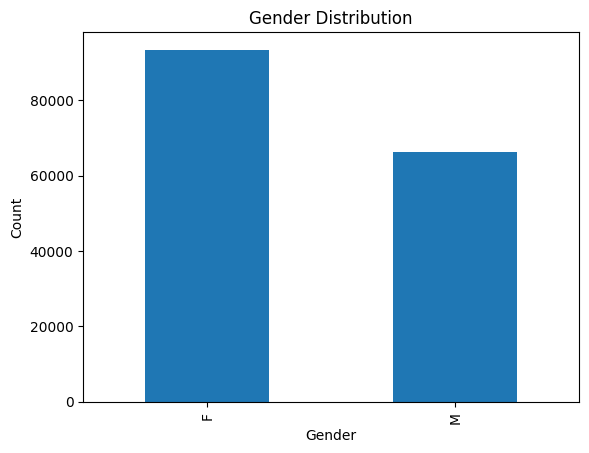

In [32]:
data['Gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [33]:
# Text Normalization
data['Name'] = data['Name'].astype(str).str.strip().str.lower()

In [34]:
# Features and target
X = data['Name']
y = data['Gender']

In [37]:
vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 4))

In [38]:
X = vectorizer.fit_transform(data['Name'])

In [40]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
    stratify=y
)

In [42]:
model = LogisticRegression(class_weight='balanced',max_iter=2000)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [43]:
# Predictions
y_pred = model.predict(X_test)

In [44]:
# Results
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8910599655550336

Classification Report:

              precision    recall  f1-score   support

           F       0.92      0.89      0.91     18681
           M       0.86      0.89      0.87     13254

    accuracy                           0.89     31935
   macro avg       0.89      0.89      0.89     31935
weighted avg       0.89      0.89      0.89     31935



In [54]:
name = ["John Smith"]

X_test = vectorizer.transform(name)
prediction = model.predict(X_test)

print(prediction)

['M']


In [51]:
name = ["A"]

X_test = vectorizer.transform(name)
prediction = model.predict(X_test)

print(prediction)

['M']
